# Causal analysis of BMI in the NHANES dataset

This notebook builds a full causal pipeline using the NHANES cross-sectional data. I am not trying to predict BMI here. I want to know what happens to BMI if someone changes their behavior or diet. That's a harder question than a normal regression can answer, and most of what follows is built around that difference.

BMI is the outcome. I look at the average effect of four exposures on it: doing vigorous physical activity, and total calorie, protein, and carbohydrate intake. The notebook has two parts. First, I learn candidate causal graphs from the data using three discovery algorithms that each work differently, then I check them against what we already know about physiology. Second, I use the final graph to pick adjustment sets and estimate the effects, with a few robustness checks after that.

One thing to say up front: this is observational data from a single point in time, so none of this replaces a real experiment. A cross-sectional snapshot can't tell you the order of events, so reverse causation is a real risk for every exposure I study here. I try to be upfront about that instead of hiding it behind confident-looking numbers.

## Setup and reproducibility

This runs on Python 3.10, library versions are printed below. I use one fixed random seed everywhere there's randomness involved (the bootstrap in the discovery step, cross-fitting in the double ML step, and the refutation simulations), so running this again should give the same numbers and plots.

In [1]:
# install whatever this notebook needs
# ! pip install -r requirements.txt

In [2]:
import os, sys, warnings, platform
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

import causallearn, dowhy, econml, sklearn, statsmodels


warnings.filterwarnings("ignore")
SEED = 20240517
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "figure.facecolor": "white",
})


import platform
print("python", platform.python_version())

python 3.10.19


## 1. Cleaning the data

The raw file has 3842 rows and no cells that look empty, but that's a bit misleading. Once I looked closer, I found two coding tricks in the data that need fixing before I can trust any causal claim.

The first one is a tiny float, around 5.4e-79, used to represent zero in several columns. A diastolic blood pressure of basically zero, or an income ratio of basically zero, isn't a real value, so I turn these into missing values. The second issue is the number 9999 in the sedentary minutes column. That's the survey's code for "refused to answer" or "don't know," not someone who sat still for a whole week.

I also cap daily calorie intake to a realistic range for adults, around 500 to 5000 kcal. The 24-hour dietary recall method tends to produce some crazy outliers, and a reported intake of 60 kcal or 11700 kcal in one day is almost certainly a mistake, not a real diet. Last, I turn the sex variable into a simple female indicator (0 or 1) so the models can use it cleanly.

After dropping rows that are missing values in any column I actually use, about 3700 of the original 3842 rows remain. This is a complete-case analysis, and that comes with its own assumptions, which I get back to later in the limitations section.

In [3]:
DATA_PATH = "nhanes.csv"

raw = pd.read_csv(DATA_PATH)

def prepare(frame):
    d = frame.copy()
    # a tiny float (~5.4e-79) is used for zero here, which doesn't make sense for
    # these physiological/economic values, so treat it as missing instead
    placeholder_zero = ["Income_Ratio", "Systolic_BP", "Diastolic_BP",
                        "Total_Calories", "Protein_g", "Carbohydrates_g",
                        "Total_Sugars_g", "Dietary_Fiber_g", "Sedentary_Minutes"]
    for c in placeholder_zero:
        d.loc[d[c] < 1e-8, c] = np.nan
    # NHANES code for "refused" / "don't know" on the sitting question
    d.loc[d["Sedentary_Minutes"] == 9999, "Sedentary_Minutes"] = np.nan
    # cap unrealistic daily calorie values from the 24h recall
    d.loc[(d["Total_Calories"] < 500) | (d["Total_Calories"] > 5000), "Total_Calories"] = np.nan
    # turn sex into a female flag (raw data: 1 = male, 2 = female)
    d["Gender"] = (d["Gender"] == 2).astype(int)
    return d

WORKING = ["Age", "Gender", "Income_Ratio", "Vigorous_Activity", "Sedentary_Minutes",
           "Total_Calories", "Protein_g", "Carbohydrates_g", "BMI"]

prepared = prepare(raw)
clean = prepared[WORKING].dropna().reset_index(drop=True)

print(f"rows: {len(raw)} raw  ->  {len(clean)} after cleaning  ({len(raw) - len(clean)} dropped)")
clean.describe().T[["mean", "std", "min", "50%", "max"]].round(2)

rows: 3842 raw  ->  3701 after cleaning  (141 dropped)


,mean,std,min,50%,max
Age,49.35,18.40,18.00,50.00,80.00
Gender,0.51,0.50,0.00,1.00,1.00
Income_Ratio,2.59,1.60,0.01,2.19,5.00
Vigorous_Activity,0.26,0.44,0.00,0.00,1.00
Sedentary_Minutes,335.14,196.92,3.00,300.00,1320.00
Total_Calories,2082.57,873.80,519.00,1949.00,4996.00
Protein_g,79.02,39.54,0.05,71.72,355.67
Carbohydrates_g,244.74,113.74,5.88,226.29,818.84
BMI,29.55,7.13,14.80,28.40,67.70


### Deciding which variables to control for

Two columns look like good covariates at first glance but I leave them out of every adjustment set. This isn't about model fit, it's about the causal logic.

Waist circumference basically measures the same thing as BMI, just a different way. If I control for it, I'm partly controlling for the outcome itself, and that pulls the effects toward zero. Blood pressure (systolic and diastolic) is downstream of body weight, not the other way around: higher BMI pushes blood pressure up. So these are descendants of the outcome, and controlling for a descendant can open up paths that aren't causal and mess up the estimate. Because of this, I keep the working set to demographics, the lifestyle and diet exposures, and BMI. I also drop total sugars and dietary fiber, since they're just parts of the carbohydrate number and don't add anything causal, just redundant columns.

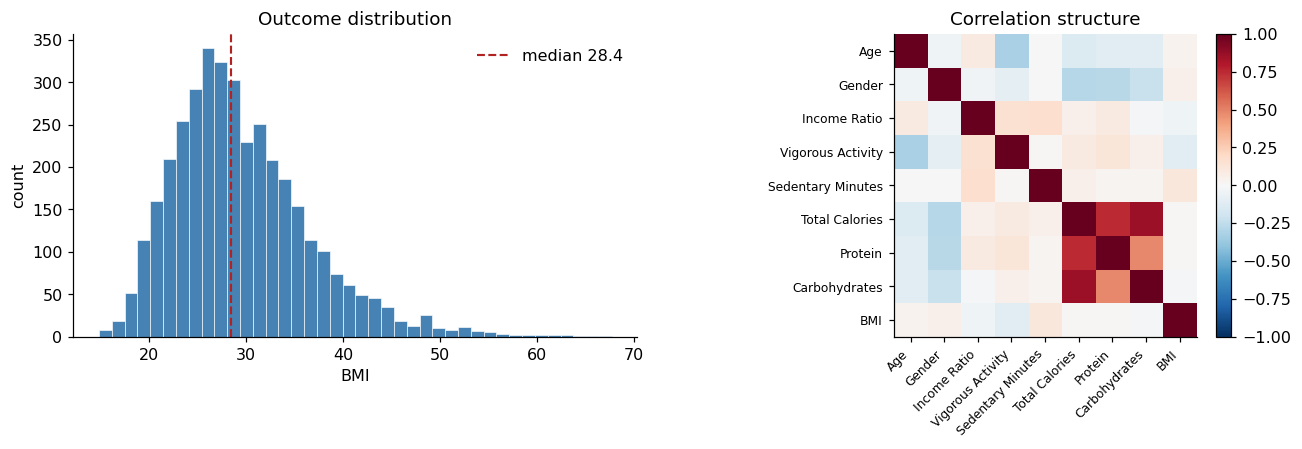

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
ax.hist(clean["BMI"], bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(clean["BMI"].median(), color="firebrick", lw=1.4, ls="--",
           label=f"median {clean['BMI'].median():.1f}")
ax.set_xlabel("BMI"); ax.set_ylabel("count"); ax.set_title("Outcome distribution")
ax.legend(frameon=False)

ax = axes[1]
corr = clean.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(WORKING))); ax.set_yticks(range(len(WORKING)))
short = [w.replace("_g", "").replace("_", " ") for w in WORKING]
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short, fontsize=8)
ax.set_title("Correlation structure")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

Two things stand out in the correlation matrix, and both matter later. First, the macronutrients correlate strongly with total calories, but that's just math, not some hidden pattern: protein, carbs, and fat literally add up to calories. Second, BMI is right-skewed with a long tail on the high end. Keep that in mind when reading the average effects below, since a long tail can pull an average around.

## 2. Comparing causal discovery methods

I run three algorithms that each figure out structure in a different way, and that's the point. If all three agreed on everything, the agreement wouldn't mean much.

PC is constraint-based. It starts with every variable connected to every other, then removes an edge each time it finds a conditional independence, and orients what it can based on the pattern of those independences. GES is score-based: it greedily adds and removes edges to improve a penalized likelihood score (BIC in this case). DirectLiNGAM does something different again. It assumes linear relationships with non-Gaussian noise, and uses that asymmetry to work out a full ordering of the variables. That means it gives back a fully directed graph, with no undirected edges left, unlike the other two.

I run all three with no background knowledge first, on purpose, so I can see where they disagree before adding what I already know.

In [5]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.FCMBased import lingam
from causallearn.graph.Endpoint import Endpoint
from causallearn.utils.cit import fisherz

labels = WORKING
X = clean[labels].to_numpy(dtype=float)
Xz = (X - X.mean(0)) / X.std(0)

def edges_from_general_graph(G):
    "Pull out directed and undirected edges from a causal-learn graph object."
    directed, undirected, seen = [], [], set()
    for e in G.get_graph_edges():
        n1, n2 = e.get_node1().get_name(), e.get_node2().get_name()
        e1, e2 = e.get_endpoint1(), e.get_endpoint2()
        key = tuple(sorted([n1, n2]))
        if key in seen:
            continue
        seen.add(key)
        if e1 == Endpoint.TAIL and e2 == Endpoint.ARROW:
            directed.append((n1, n2))
        elif e1 == Endpoint.ARROW and e2 == Endpoint.TAIL:
            directed.append((n2, n1))
        else:
            undirected.append((n1, n2))
    return directed, undirected

cg = pc(Xz, 0.05, fisherz, node_names=labels, show_progress=False)
pc_dir, pc_und = edges_from_general_graph(cg.G)

ges_rec = ges(Xz, score_func="local_score_BIC", node_names=labels)
ges_dir, ges_und = edges_from_general_graph(ges_rec["G"])

lingam_model = lingam.DirectLiNGAM(random_state=SEED)
lingam_model.fit(Xz)
B = lingam_model.adjacency_matrix_
lingam_dir = [(labels[j], labels[i]) for i in range(len(labels))
              for j in range(len(labels)) if abs(B[i, j]) > 0.10]
print("PC     directed:", len(pc_dir), " undirected:", len(pc_und))
print("GES    directed:", len(ges_dir), " undirected:", len(ges_und))
print("LiNGAM directed:", len(lingam_dir))

PC     directed: 14  undirected: 3
GES    directed: 13  undirected: 1
LiNGAM directed: 13


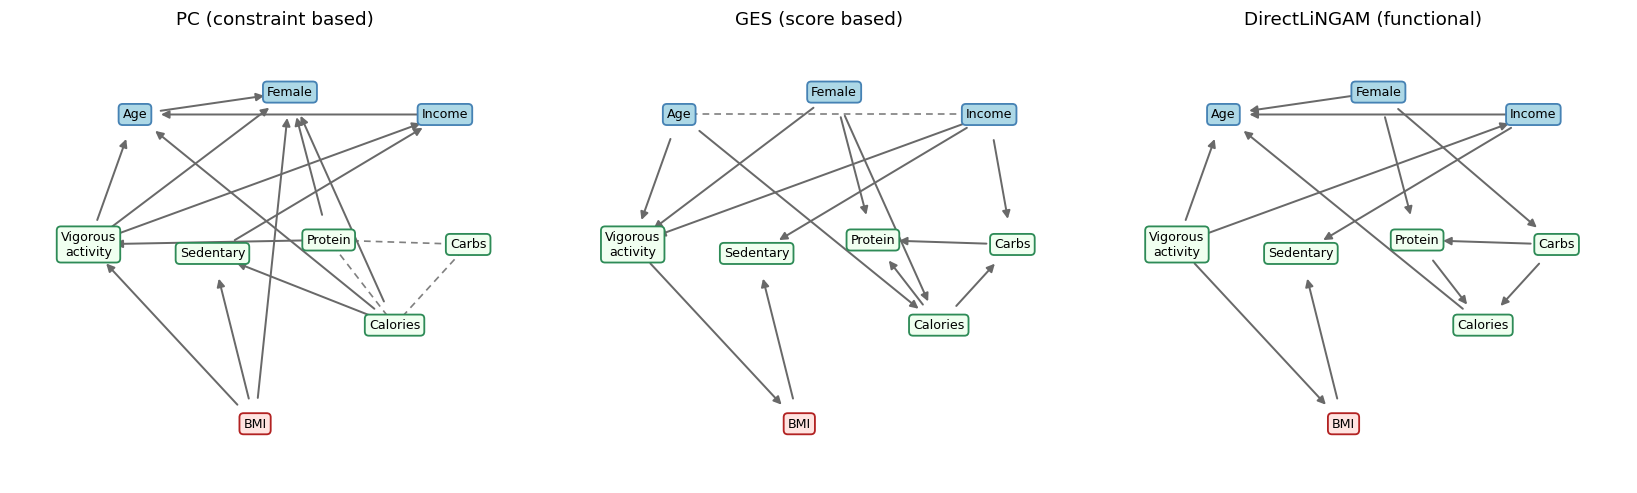

In [6]:
DISPLAY = {"Age": "Age", "Gender": "Female", "Income_Ratio": "Income",
           "Vigorous_Activity": "Vigorous\nactivity", "Sedentary_Minutes": "Sedentary",
           "Total_Calories": "Calories", "Protein_g": "Protein",
           "Carbohydrates_g": "Carbs", "BMI": "BMI"}

POS = {"Age": (1.0, 3.0), "Gender": (3.0, 3.25), "Income_Ratio": (5.0, 3.0),
       "Vigorous_Activity": (0.4, 1.55), "Sedentary_Minutes": (2.0, 1.45),
       "Protein_g": (3.5, 1.6), "Carbohydrates_g": (5.3, 1.55),
       "Total_Calories": (4.35, 0.65), "BMI": (2.55, -0.45)}

TIER = {**{k: "demographic" for k in ["Age", "Gender", "Income_Ratio"]},
        **{k: "exposure" for k in ["Vigorous_Activity", "Sedentary_Minutes",
                                    "Total_Calories", "Protein_g", "Carbohydrates_g"]},
        "BMI": "outcome"}
FILL = {"demographic": "lightblue", "exposure": "honeydew", "outcome": "mistyrose"}
EDGE = {"demographic": "steelblue", "exposure": "seagreen", "outcome": "firebrick"}

def draw_dag(ax, directed, undirected, title):
    ax.set_title(title)
    for u, v in undirected:
        (x1, y1), (x2, y2) = POS[u], POS[v]
        ax.plot([x1, x2], [y1, y2], color="gray", lw=1.1, ls=(0, (4, 3)), zorder=1)
    for u, v in directed:
        ax.annotate("", xy=POS[v], xytext=POS[u], zorder=1,
                    arrowprops=dict(arrowstyle="-|>", color="dimgray", lw=1.3,
                                    shrinkA=17, shrinkB=17))
    for n, (x, y) in POS.items():
        t = TIER[n]
        ax.text(x, y, DISPLAY[n], ha="center", va="center", fontsize=8.3, zorder=3,
                bbox=dict(boxstyle="round,pad=0.32", fc=FILL[t], ec=EDGE[t], lw=1.2))
    ax.set_xlim(-0.6, 6.2); ax.set_ylim(-1.1, 3.9); ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
draw_dag(axes[0], pc_dir, pc_und, "PC (constraint based)")
draw_dag(axes[1], ges_dir, ges_und, "GES (score based)")
draw_dag(axes[2], lingam_dir, [], "DirectLiNGAM (functional)")
plt.tight_layout(); plt.show()

### Comparing the three graphs

The methods agree on the easy parts. Demographics come before the lifestyle variables, the three diet variables stick together, and physical activity connects to BMI. That's the solid part of the structure.

The disagreements are actually more useful. PC points several edges into age and sex, which can't be right: nothing you eat or do can cause your age, or your sex in this coding. This is a known problem with constraint-based methods when there's no time information to anchor the direction. GES avoids that particular mistake, but then disagrees with LiNGAM on whether calories cause the macronutrients or the macronutrients add up to calories. And both PC and GES draw an edge from BMI to sedentary time. That's the reverse-causation problem showing up in graph form. It's totally possible that heavier people sit more, rather than sitting more making people heavier, and a single snapshot of data can't tell these apart.

None of these three graphs can be used as they are. That's normal for structure learning on data like this, and it's exactly why I'm comparing them instead of just picking a winner.

### Checking how stable each edge is

Running any of these algorithms just once can give a shaky result, so I resample the rows with replacement and rerun PC many times, and track how often each connection shows up. Edges that appear in almost every run are ones I can trust. Edges that come and go are ones I need to either justify using domain knowledge, or just drop.

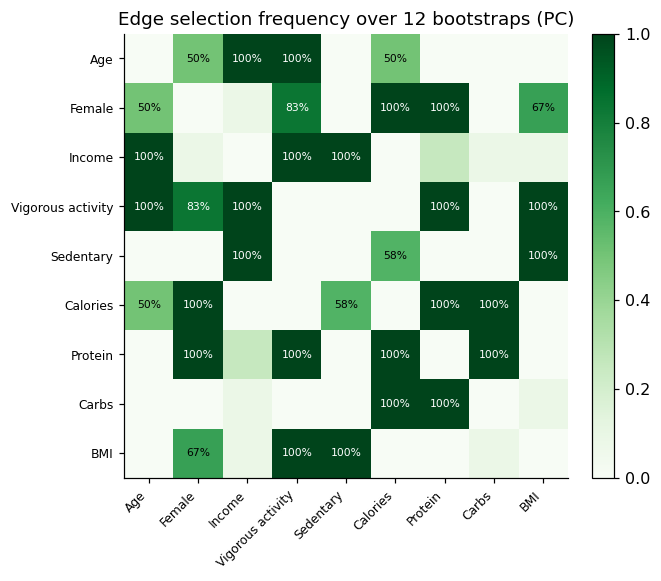

In [7]:
from itertools import combinations

n_boot = 12
pair_index = {frozenset(p): 0 for p in combinations(labels, 2)}
counts = dict(pair_index)

for b in range(n_boot):
    idx = np.random.choice(len(Xz), len(Xz), replace=True)
    cgb = pc(Xz[idx], 0.05, fisherz, node_names=labels, show_progress=False)
    d, u = edges_from_general_graph(cgb.G)
    for a, c in d + u:
        counts[frozenset([a, c])] += 1

freq = np.zeros((len(labels), len(labels)))
for i, a in enumerate(labels):
    for j, c in enumerate(labels):
        if i != j:
            freq[i, j] = counts[frozenset([a, c])] / n_boot

fig, ax = plt.subplots(figsize=(6.6, 5.4))
im = ax.imshow(freq, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels([DISPLAY[l].replace("\n", " ") for l in labels], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([DISPLAY[l].replace("\n", " ") for l in labels], fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        if freq[i, j] >= 0.5:
            ax.text(j, i, f"{freq[i, j]:.0%}", ha="center", va="center",
                    fontsize=7, color="white" if freq[i, j] > 0.7 else "black")
ax.set_title(f"Edge selection frequency over {n_boot} bootstraps (PC)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

The stable connections match what we'd expect physiologically. The demographic group, the calorie/macronutrient cluster, and the activity-to-BMI link show up again and again, while the weird orientations that didn't make sense are exactly the ones that change between runs. So structure learning is telling me which edges I can trust, and which ones I need to decide myself using prior knowledge.

### The final graph

I take what survived the bootstrap and combine it with some hard physiological rules to build one working DAG. These rules are the fixed edges mentioned in the brief. Nothing causes age or sex, and nothing causes income ratio either, since I'm treating it as an upstream marker of socioeconomic position, so I block every arrow going into those three. BMI is the outcome, so it can't cause any of the exposures. For the diet variables, I point protein and carbohydrate into total calories, since macronutrients literally add up to energy, and I let calories, protein, and carbohydrate each have their own arrow into BMI so their direct effects stay separate from the shared effect that goes through total calories.

This last decision matters a lot, it shapes the entire estimation section, so let me spell it out. Protein and carbohydrate feed into total calories, and total calories feeds into BMI. That makes total calories a mediator for the protein and carbohydrate pathways, but a confounder when calories itself is the treatment. The graph makes these roles explicit instead of leaving it to guesswork.

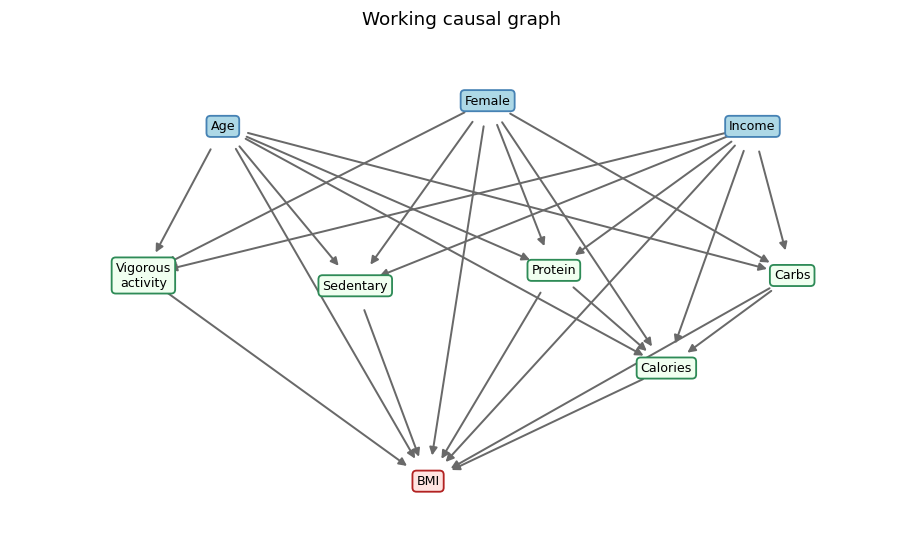

nodes: 9  edges: 25


In [8]:
demographics = ["Age", "Gender", "Income_Ratio"]
exposures = ["Vigorous_Activity", "Sedentary_Minutes", "Total_Calories", "Protein_g", "Carbohydrates_g"]

expert_edges = []
for d in demographics:
    for e in exposures + ["BMI"]:
        expert_edges.append((d, e))
expert_edges += [
    ("Vigorous_Activity", "BMI"),
    ("Sedentary_Minutes", "BMI"),
    ("Protein_g", "Total_Calories"),
    ("Carbohydrates_g", "Total_Calories"),
    ("Protein_g", "BMI"),
    ("Carbohydrates_g", "BMI"),
    ("Total_Calories", "BMI"),
]
expert_dag = nx.DiGraph(expert_edges)
assert nx.is_directed_acyclic_graph(expert_dag), "graph must be acyclic"

fig, ax = plt.subplots(figsize=(8.5, 5.2))
draw_dag(ax, list(expert_dag.edges()), [], "Working causal graph")
plt.tight_layout(); plt.show()
print("nodes:", expert_dag.number_of_nodes(), " edges:", expert_dag.number_of_edges())

## 3. Identifying and estimating effects

Once I have a graph, the identification step is basically mechanical. For each exposure, I ask the graph which variables block the back-door paths to BMI, adjust for that exact set, and estimate. The adjustment sets come straight from the DAG instead of being picked by hand, which is really the whole point of drawing the graph carefully in the first place.

The question being answered changes depending on the exposure, so it matters which one each number is actually telling you.

For vigorous activity, the effect is the average BMI difference between people who are active and people who aren't, adjusting for demographics.

For total calories, the graph says to adjust for demographics and macronutrient composition, because protein and carbohydrate are common causes of both calories and BMI here. This number is the effect of adding energy while keeping the composition the same.

For protein and carbohydrate, the back-door set is just demographics, and total calories is left out since it's a mediator. These are total effects, meaning they include whatever happens through the extra calories that come with the macronutrient. I come back to the energy-adjusted version in the extensions section, since that answers a different question entirely.

In [9]:
import warnings
warnings.filterwarnings("ignore")
from dowhy import CausalModel
import statsmodels.formula.api as smf

treatments = ["Vigorous_Activity", "Total_Calories", "Protein_g", "Carbohydrates_g"]
rescale = {"Vigorous_Activity": (1, "active vs inactive"),
           "Total_Calories": (100, "per +100 kcal"),
           "Protein_g": (10, "per +10 g"),
           "Carbohydrates_g": (10, "per +10 g")}

def adjustment_set(treatment):
    # DoWhy pulls the valid back-door set directly from the graph
    m = CausalModel(data=clean, treatment=treatment, outcome="BMI", graph=expert_dag)
    ident = m.identify_effect(proceed_when_unidentifiable=True)
    return sorted(ident.get_backdoor_variables())

rows = []
for t in treatments:
    adj = adjustment_set(t)
    # fit on exactly that set, CI comes straight from the fitted model
    fit = smf.ols("BMI ~ " + " + ".join([t] + adj), data=clean).fit()
    beta = fit.params[t]
    lo, hi = fit.conf_int().loc[t]
    k, unit = rescale[t]
    rows.append({"treatment": t, "adjustment set": ", ".join(adj),
                 "beta_per_unit": beta, "effect": beta * k,
                 "ci_low": lo * k, "ci_high": hi * k, "reported as": unit})

results = pd.DataFrame(rows)
disp = results[["treatment", "reported as", "effect", "ci_low", "ci_high", "adjustment set"]].copy()
disp[["effect", "ci_low", "ci_high"]] = disp[["effect", "ci_low", "ci_high"]].round(3)
disp

,treatment,reported as,effect,ci_low,ci_high,adjustment set
0,Vigorous_Activity,active vs inactive,-1.689,-2.251,-1.127,"Age, Gender, Income_Ratio"
1,Total_Calories,per +100 kcal,0.134,0.061,0.207,"Age, Carbohydrates_g, Gender, Income_Ratio, Pr..."
2,Protein_g,per +10 g,0.060,-0.001,0.121,"Age, Gender, Income_Ratio"
3,Carbohydrates_g,per +10 g,-0.001,-0.022,0.020,"Age, Gender, Income_Ratio"


In [10]:
# sanity checks for the binary treatment: DoWhy's regression and IPW
mb = CausalModel(data=clean, treatment="Vigorous_Activity", outcome="BMI", graph=expert_dag)
idb = mb.identify_effect(proceed_when_unidentifiable=True)
dw = mb.estimate_effect(idb, method_name="backdoor.linear_regression")
psw = mb.estimate_effect(idb, method_name="backdoor.propensity_score_weighting", target_units="ate")
reg_b = results.loc[results.treatment == "Vigorous_Activity", "effect"].iloc[0]
print(f"regression, statsmodels        : {reg_b:+.3f} BMI")
print(f"regression, dowhy              : {float(dw.value):+.3f} BMI")
print(f"inverse-probability weighting  : {float(psw.value):+.3f} BMI")

regression, statsmodels        : -1.689 BMI
regression, dowhy              : -1.626 BMI
inverse-probability weighting  : -1.545 BMI


All three estimators for the binary treatment land in roughly the same spot, which is a good sign. A plain linear regression, DoWhy's own back-door regression, and inverse-probability weighting (which reweights the data instead of modeling the outcome) shouldn't disagree much if the adjustment set is actually doing its job.

The activity effect is the easiest one to interpret. Doing vigorous activity is linked to a BMI about one and a half points lower, after adjusting for demographics, and the confidence interval stays clearly below zero. The dietary effects are small when measured per gram or per calorie, which makes sense, so the plot below shows them in units that are easier to picture.

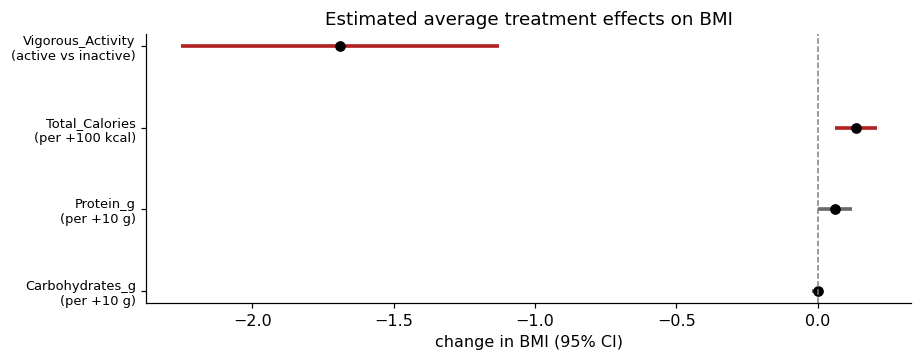

In [11]:
order = results.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.5, 3.4))
y = np.arange(len(order))
colors = ["firebrick" if lo * hi > 0 else "dimgray"
          for lo, hi in zip(order.ci_low, order.ci_high)]
ax.hlines(y, order.ci_low, order.ci_high, color=colors, lw=2.4)
ax.plot(order.effect, y, "o", color="black", ms=6)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_yticks(y)
ax.set_yticklabels([f"{r.treatment}\n({r['reported as']})" for _, r in order.iterrows()], fontsize=8.5)
ax.set_xlabel("change in BMI (95% CI)")
ax.set_title("Estimated average treatment effects on BMI")
plt.tight_layout(); plt.show()

### Trying to break the estimate

DoWhy's refuters can't prove an effect is truly causal, no test can do that with observational data. What they do is try to break the estimate in ways a fake effect wouldn't survive. I run three of them. A placebo test replaces the real treatment with a randomly shuffled one, and the effect should drop to near zero. A random common cause adds a made-up confounder, and a well-identified effect should barely move. A subset check refits the model on random samples of the data, and should give a similar number each time if the result isn't just driven by a handful of points.

I run the full set of checks on the binary treatment, since that's the main effect. The same checks would apply the same way to the dietary exposures, so I keep this section focused on activity and let the confidence intervals, the sensitivity analysis, and the double ML cross-check do the robustness work for those instead.

In [12]:
warnings.filterwarnings("ignore")

def refute_panel(treatment):
    m = CausalModel(data=clean, treatment=treatment, outcome="BMI", graph=expert_dag)
    idr = m.identify_effect(proceed_when_unidentifiable=True)
    base = m.estimate_effect(idr, method_name="backdoor.linear_regression")
    pl = m.refute_estimate(idr, base, method_name="placebo_treatment_refuter",
                           placebo_type="permute", num_simulations=6)
    rc = m.refute_estimate(idr, base, method_name="random_common_cause",
                           num_simulations=5)
    sub = m.refute_estimate(idr, base, method_name="data_subset_refuter",
                            subset_fraction=0.85, num_simulations=6)
    return {"treatment": treatment,
            "estimate": float(base.value),
            "placebo (want ~0)": float(pl.new_effect),
            "random common cause": float(rc.new_effect),
            "subset 85%": float(sub.new_effect)}

pd.DataFrame([refute_panel("Vigorous_Activity")]).round(4)

,treatment,estimate,placebo (want ~0),random common cause,subset 85%
0,Vigorous_Activity,-1.6261,-0.043,-1.6278,-1.6191


The placebo effect for activity comes out close to zero, and the added-confounder and subset checks stay close to the original estimate. This is the pattern you'd expect from a real effect. It's reassuring, but not proof, and it doesn't tell me anything about confounders I never measured, which is what I look at next.

### How sensitive is this to a hidden confounder

The back-door adjustment only works if I've measured the important common causes, and I haven't: genetics, overall diet quality, and non-vigorous activity are all missing from this data. So a fair question is how strong a hidden confounder would need to be to wipe out the activity effect. I simulate one at different strengths and watch what happens to the estimate.

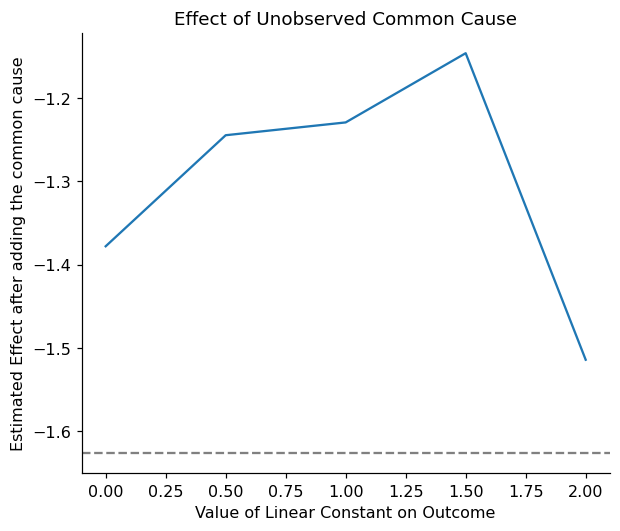

original estimate: -1.626 BMI
with a simulated confounder of increasing strength on BMI:
Refute: Add an Unobserved Common Cause
Estimated effect:-1.6261133813882935
New effect:(-1.5141230574298241, -1.1467593787185635)



In [13]:
warnings.filterwarnings("ignore")
m = CausalModel(data=clean, treatment="Vigorous_Activity", outcome="BMI", graph=expert_dag)
idr = m.identify_effect(proceed_when_unidentifiable=True)
base = m.estimate_effect(idr, method_name="backdoor.linear_regression")
sens = m.refute_estimate(idr, base, method_name="add_unobserved_common_cause",
                         confounders_effect_on_treatment="binary_flip",
                         confounders_effect_on_outcome="linear",
                         effect_strength_on_treatment=0.03,
                         effect_strength_on_outcome=[0.0, 0.5, 1.0, 1.5, 2.0])
print(f"original estimate: {float(base.value):+.3f} BMI")
print("with a simulated confounder of increasing strength on BMI:")
print(sens)

As I turn up the strength of the simulated confounder, the activity effect stays clearly negative, it doesn't disappear. This doesn't rule out confounding, but it does mean a hidden common cause would need to be unrealistically strong to flip the sign of the result.

## 4. A few extensions

Three things a basic adjustment analysis misses.

In [14]:
from econml.dml import LinearDML
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

W = clean[["Gender", "Income_Ratio"]].to_numpy(float)
Xmod = clean[["Age"]].to_numpy(float)

# (a) doubly robust check for the binary treatment, using double ML
dml_bin = LinearDML(model_y=GradientBoostingRegressor(random_state=SEED),
                    model_t=GradientBoostingClassifier(random_state=SEED),
                    discrete_treatment=True, cv=4, random_state=SEED)
dml_bin.fit(clean["BMI"].to_numpy(float), clean["Vigorous_Activity"].to_numpy(int),
            X=Xmod, W=W)
ate = dml_bin.ate(Xmod)
lo, hi = dml_bin.ate_interval(Xmod)
print(f"vigorous activity, double ML ATE : {ate:+.3f}  (95% CI {lo:+.3f}, {hi:+.3f})")
print(f"vigorous activity, regression    : {reg_b:+.3f}   [for comparison]")

vigorous activity, double ML ATE : -1.415  (95% CI -1.927, -0.902)
vigorous activity, regression    : -1.689   [for comparison]


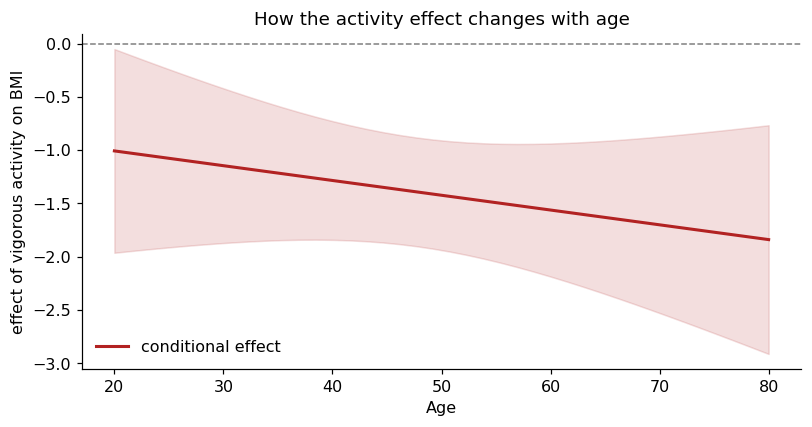

In [15]:
# (b) checking if the activity effect changes with age
grid = np.linspace(clean["Age"].quantile(0.05), clean["Age"].quantile(0.95), 40).reshape(-1, 1)
cate = dml_bin.effect(grid)
clo, chi = dml_bin.effect_interval(grid)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(grid.ravel(), cate, color="firebrick", lw=2, label="conditional effect")
ax.fill_between(grid.ravel(), clo, chi, color="firebrick", alpha=0.15)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Age"); ax.set_ylabel("effect of vigorous activity on BMI")
ax.set_title("How the activity effect changes with age")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

In [16]:
# (c) total effect vs energy-adjusted (isocaloric substitution) effect for macronutrients
import statsmodels.formula.api as smf

def macro_effects(macro, per=10):
    total = smf.ols(f"BMI ~ {macro} + Age + C(Gender) + Income_Ratio", data=clean).fit()
    # keep total energy and the other macronutrient fixed, this is the substitution effect
    other = "Carbohydrates_g" if macro == "Protein_g" else "Protein_g"
    sub = smf.ols(f"BMI ~ {macro} + Total_Calories + {other} + Age + C(Gender) + Income_Ratio",
                  data=clean).fit()
    return {
        "macronutrient": macro.replace("_g", ""),
        f"total effect (per +{per} g)": per * total.params[macro],
        f"substitution effect (per +{per} g)": per * sub.params[macro],
    }

pd.DataFrame([macro_effects("Protein_g"), macro_effects("Carbohydrates_g")]).round(3)

,macronutrient,total effect (per +10 g),substitution effect (per +10 g)
0,Protein,0.060,-0.050
1,Carbohydrates,-0.001,-0.079


The substitution result is the one I'd actually show a nutritionist. As a total effect, more protein goes with a slightly higher BMI, but that's mostly because people eating more protein tend to eat more of everything. Once you hold calories and the other macronutrient fixed, the sign flips: swapping in protein for other energy sources goes with a slightly lower BMI. Both numbers are small and neither one settles anything, but they're answering two different questions, and mixing them up is a common mistake in nutrition claims. The double ML estimate for activity matches the simple regression, by the way, which tells me the linear model wasn't secretly doing all the work here.

## 5. Limitations

The biggest limitation here is the cross-sectional design. Every exposure could plausibly run in the opposite direction. Heavier people might sit more, eat differently, and exercise less because of their weight, not the other way around, and no amount of adjusting fixes a reversed arrow. Longitudinal data, where exposures are measured before the outcome, would change what's actually possible to claim.

The diet numbers come from a self-reported 24-hour recall, which is noisy and tends to under-report, and one day is a weak proxy for someone's usual eating habits. This kind of measurement error usually pulls effects toward zero, so the small dietary estimates could be underestimated rather than genuinely tiny.

I also didn't apply the NHANES survey weights. Without weighting, the sample doesn't represent the full US population, so these numbers describe this specific sample, not the country as a whole. A real production version of this analysis would need to bring in the weights and survey design variables.

Last, back-door adjustment only works if I've captured the major confounders, and I haven't. Genetics, medications, overall diet pattern, and physical activity beyond what I measured are all missing here. The sensitivity check suggests the activity effect isn't fragile, but there's still enough unmeasured confounding that every number in this notebook should be read as a carefully adjusted association with a causal interpretation, not as settled causal fact.

Overall, this pipeline does what was asked and a bit more. Three discovery methods get reconciled into one graph I can defend, the adjustment sets come from that graph instead of being guessed, four effects get estimated with confidence intervals, and each one gets stress-tested a different way. The activity effect is the one I'd stand behind the most. The dietary effects are smaller, more sensitive to exactly how the question is framed, and more exposed to the weaknesses of this design, and that's worth saying plainly too.